In [1]:
#Se instalan las librerías necesarias para leer datos del servidor de la NOAA
!pip install xarray netCDF4 pandas numpy matplotlib

   ---------------------------------------- 0.0/21.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/21.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/21.3 MB 435.7 kB/s eta 0:00:49
   ---------------------------------------- 0.1/21.3 MB 1.4 MB/s eta 0:00:15
   -- ------------------------------------- 1.5/21.3 MB 9.6 MB/s eta 0:00:03
   ------ --------------------------------- 3.6/21.3 MB 19.0 MB/s eta 0:00:01
   ----------- ---------------------------- 5.9/21.3 MB 25.2 MB/s eta 0:00:01
   ---------------- ----------------------- 8.7/21.3 MB 31.0 MB/s eta 0:00:01
   ------------------- -------------------- 10.5/21.3 MB 46.9 MB/s eta 0:00:01
   ------------------------ --------------- 13.0/21.3 MB 59.5 MB/s eta 0:00:01
   ----------------------------- ---------- 15.8/21.3 MB 54.7 MB/s eta 0:00:01
   --------------------------------- ------ 18.0/21.3 MB 59.5 MB/s eta 0:00:01
   ------------------------------------- -- 19.8/21.3 MB 54.4 MB/s eta 0:00:0

In [6]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#URL del servidor OpenDAP de la NOAA - Temperatura del aire en superficie, medias a largo plazo
url = "http://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis.derived/surface/air.mon.ltm.nc"
ds = xr.open_dataset(url)

c:\Users\lucap\anaconda3\Lib\site-packages\xarray\coding\times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
c:\Users\lucap\anaconda3\Lib\site-packages\xarray\core\indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


In [ ]:
#Se promedia el tiempo -para tener el clima anual- y la longitud -para tener el promedio zonal-
temp_anual = ds['air'].mean(dim='time')
temp_zonal = temp_anual.mean(dim='lon')

#Se extraen los valores de latitudes y las temperaturas
latitudes_grados = ds['lat'].values
temperaturas_c = temp_zonal.values

#Se normalizan las latitudes entre -1 y 1 con la transformación senoidal
x_seno = np.sin(np.deg2rad(latitudes_grados))

df = pd.DataFrame({
    'latitud_grados': latitudes_grados,
    'x_seno': x_seno,
    'temperatura_C': temperaturas_c,
    'temperatura_K': temperaturas_c + 273.15  # Kelvin es OBLIGATORIO para la radiación
})

#Se ordena de sur a norte
df = df.sort_values(by='x_seno').reset_index(drop=True)

display(df.head())

,latitud_grados,x_seno,temperatura_C,temperatura_K
0,-90.0,-1.000000,-44.292564,228.857422
1,-87.5,-0.999048,-41.433094,231.716904
2,-85.0,-0.996195,-36.200111,236.949890
3,-82.5,-0.991445,-33.903435,239.246552
4,-80.0,-0.984808,-33.840401,239.309601


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\lucap\AppData\Local\Temp\ipykernel_55824\354365246.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Variable espacial $x = \sin(latitud)$ [-1: Polo Sur, 1: Polo Norte]', fontsize=12)


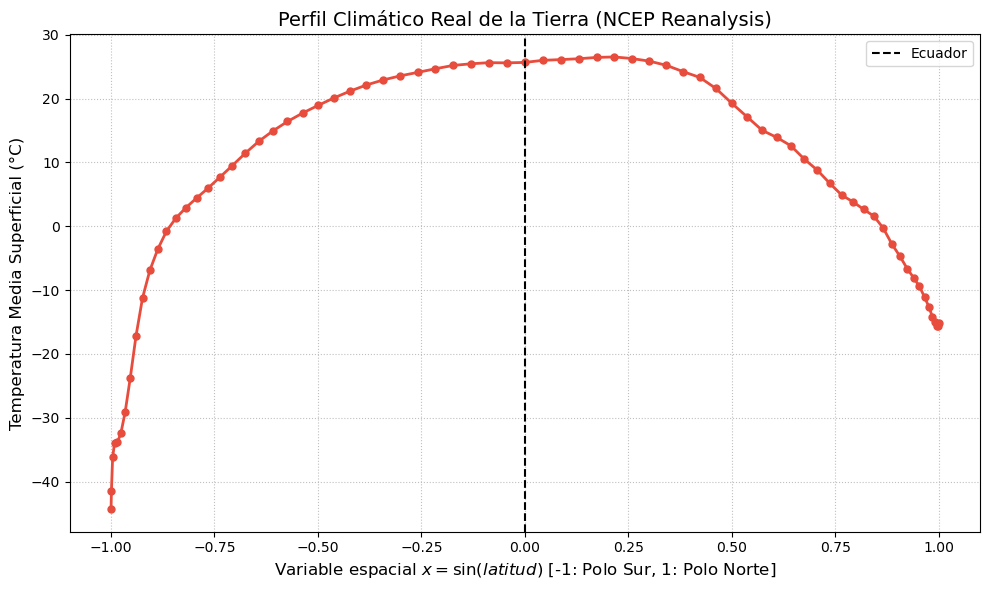

In [8]:
plt.figure(figsize=(10, 6))
#Temperatura en función de x
plt.plot(df['x_seno'], df['temperatura_C'], 'o-', color='#e74c3c', linewidth=2, markersize=5)

plt.title('Perfil Climático Real de la Tierra (NCEP Reanalysis)', fontsize=14)
plt.xlabel('Variable espacial $x = \sin(latitud)$ [-1: Polo Sur, 1: Polo Norte]', fontsize=12)
plt.ylabel('Temperatura Media Superficial (°C)', fontsize=12)

#Referencias
plt.axvline(0, color='black', linewidth=1.5, linestyle='--', label='Ecuador')
plt.grid(True, linestyle=':', alpha=0.8)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
import os
ruta_guardado = '../data/temp_latitudinal.csv'
df.to_csv(ruta_guardado, index=False)